<a href="https://colab.research.google.com/github/stivenjosez/An-lisis-ConnectaTel/blob/main/S7_Version_Estudiante_Project_ConnectaTel_limpio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel.

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


---
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [ ]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [ ]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [ ]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [ ]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [ ]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [ ]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [ ]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [ ]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [ ]:
# cantidad de nulos para users
print(users.isna().sum().sort_values(ascending=False))
print(users.isna().mean() * 100)

churn_date    3534
city           469
user_id          0
first_name       0
last_name        0
age              0
reg_date         0
plan             0
dtype: int64
user_id        0.000
first_name     0.000
last_name      0.000
age            0.000
city          11.725
reg_date       0.000
plan           0.000
churn_date    88.350
dtype: float64


In [ ]:
# cantidad de nulos para usage
print(usage.isna().sum().sort_values(ascending=False))
print(usage.isna().mean() * 100)

duration    22076
length      17896
date           50
id              0
user_id         0
type            0
dtype: int64
id           0.000
user_id      0.000
type         0.000
date         0.125
duration    55.190
length      44.740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos.

 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
- Del dataset de users contamos con dos columnas con nulos que serian churn_date con un porcentajede nulos del 88% aproximadamente y city con un porcentaje de 12% aproximadamente.
- Del dataset de usage contamos con 3 columnas que contienen nulos, date con un 0.125%, duration con un 55% aproximadamente y length con un 45% aproximadamente de nulos
- Indica qué harías: ¿imputar, eliminar, ignorar?
- en el dateset de users la columna de churn_date se recomienda eliminar debido a su alta cantidad de nulo, en cambio la columna de city se recomienda realizar una investigacion para osea imputar o dejar como nulos dependiendo cual sea mejor aplicar.
- En el dataset de usuage para la columna date seria realizar una imputacion y para las columnas de duration y leght que presentan un porcentaje parecido de nulos seria investigacion para tomar una decision que impugnar o dejar nulos o dependiendo el caso se podria llegar a eliminar

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [ ]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` aunque es una columna numerica su naturaleza es categorica al no presentar valores nulos sus datos no presentan ninguna anomalia.
- La columna `age` presenta un sesgo a la izquierda debido a que el promedio es mucho menor a la mediana de los datos, se puede comprobar a revisar el minimo es un valor ilogico.

In [ ]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` al ser categoricas y no contar con valores nulos son estables con los datos sin presentar ninguna anomalia.
- Las columnas `duration` y `length` Se observa una discrepancia significativa en el conteo de registros válidos (duration con $17,924$ y length con $22,104$ observaciones no nulas).   Existe un marcado sesgo a la derecha en ambas métricas, evidenciado por una media superior a la mediana ($50\%$). En el caso de duration, la media supera al valor central de forma notable, y para length, la presencia de un valor máximo atípico ($1,490.0$) frente a un tercer cuartil de $64.0$ indica la existencia de outliers (valores atípicos extremos) que influyen directamente en la dispersión (std)

In [ ]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].describe()

,city,plan
count,3531,4000
unique,7,2
top,Bogotá,Basico
freq,808,2595


- La columna `city` podemos corroborar la cantidad de valores no nulos y la ciudad con un mayor frecuencia es Bogotá
- La columna `plan` no hay ninguna anomalia, no hay valores nulos y el plan basico cuenta con la mayor frecuencia con mas del 50%

In [ ]:
# explorar columna categórica de usage
usage['type'].describe()

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

- La columna `type` no presenta ningun valor nulo y de las dos categorias la que presenta la mayor frecuencia es text con mas del 50%


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
- Los valores invalidos o sentinels se encontrareon mayormente en columnas numericas como lo son duration, length los cuales presentan un marcado sesgo a la derecha debido a valores extremos mucho mayores al 3 quartil com se observo en el analisis
- ¿Qué acción tomarías?
- seguir investigando a que se debe para tomar la decision de imputar o eliminar dichas columnas si son irrelevantes para el analisis

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [ ]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors="coerce")

In [ ]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors="coerce")

In [ ]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].value_counts()

2026-05-10 00:00:00.000000000    40
2023-12-20 18:33:45.506376600     1
2022-11-21 17:58:06.571642912     1
2024-06-20 09:50:54.463615904     1
2022-05-22 00:23:45.956489122     1
                                 ..
2022-07-29 04:44:06.661665416     1
2022-02-22 00:36:43.750937734     1
2022-10-31 09:22:49.242310580     1
2022-09-24 16:46:48.702175544     1
2022-03-28 12:38:20.975243811     1
Name: reg_date, Length: 3961, dtype: int64

En `reg_date`, hay 40 valores del 2026 que no corresponden a los años de estudio

In [ ]:
# Revisar los años presentes en `date` de usage
usage['date'].value_counts()

2024-06-16 13:26:59.770494262    1
2024-06-21 22:28:11.862296556    1
2024-06-06 11:09:26.204155102    1
2024-04-14 16:05:21.848046200    1
2024-04-01 14:39:43.079576989    1
                                ..
2024-04-13 22:49:17.653941348    1
2024-03-06 03:52:44.749118728    1
2024-03-21 23:20:13.140328508    1
2024-01-07 00:52:33.678841971    1
2024-04-08 01:44:47.917197929    1
Name: date, Length: 39950, dtype: int64

En `date`, todas las fechas vistas se encuentran dentro del rango de analisis del estudio
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
- en el datefren de users en la columna de reg_date podemos ver 40 valores fuera de fechas no transcurridas al momento del estudio
- ¿Qué harías con ellas?
- Al ser un porcentaje muy pequeño de los valores que se encuentran fuera de fecha se podria elimianr dichas filas

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [ ]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [ ]:
# Reemplazar ? por NA en city
users.loc[users['city'] == '?', 'city'] = np.nan

# Verificar cambios
users['city'].value_counts()

Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [ ]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'] > '2024-12-31', 'reg_date'] = np.nan

# Verificar cambios
print(f"Valores nulos generados: {users['reg_date'].isna().sum()}")
users['reg_date'].describe(datetime_is_numeric=True)

Valores nulos generados: 40


count                             3960
mean     2023-07-03 21:39:41.095273728
min                2022-01-01 00:00:00
25%      2022-10-02 20:17:11.657914368
50%      2023-07-04 10:00:05.401350400
75%      2024-04-03 04:00:05.401350400
max                2024-12-31 00:00:00
Name: reg_date, dtype: object

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [ ]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [ ]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length` ambas filas tienen el mismo tipo de missingness, el cual es "MNAR" Missing Not At Random esto porque los valoes faltantes no son casualidad es porque las columnas dependen directamente del 'tipe', un text no tiene una duracion y una call no tiene una lengt para el mensaje

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico.

**Instrucciones:**:
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [ ]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    "is_text": "sum",
    "is_call": "sum",
    "duration": "sum"
}).reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={"is_text":"cant_mensajes","is_call":"cant_llamadas","duration":"cant_minutos_llamada"})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [ ]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [ ]:
# Resumen estadístico de las columnas numéricas
cols_numericas = ['age','cant_mensajes','cant_llamadas','cant_minutos_llamada']
def ver_cols(col):
    print('Columna:', col)
    print('Valor Máximo:', user_profile[col].max())
    print('Valor Mínimo:', user_profile[col].min())
    print('Valor Promedio:', user_profile[col].mean())
    print('Valor Medio:', user_profile[col].median())
    print()

for col in cols_numericas:
    ver_cols(col)


Columna: age
Valor Máximo: 79.0
Valor Mínimo: 18.0
Valor Promedio: 48.12225
Valor Medio: 47.0

Columna: cant_mensajes
Valor Máximo: 17.0
Valor Mínimo: 0.0
Valor Promedio: 5.524381095273818
Valor Medio: 5.0

Columna: cant_llamadas
Valor Máximo: 15.0
Valor Mínimo: 0.0
Valor Promedio: 4.478119529882471
Valor Medio: 4.0

Columna: cant_minutos_llamada
Valor Máximo: 155.69
Valor Mínimo: 0.0
Valor Promedio: 23.31705426356589
Valor Medio: 19.78



In [ ]:
# Distribución porcentual del tipo de plan
user_profile['plan'].value_counts(normalize=True)*100

Basico     64.875
Premium    35.125
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada`

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda)

**Hint**  
Para cada histograma,
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

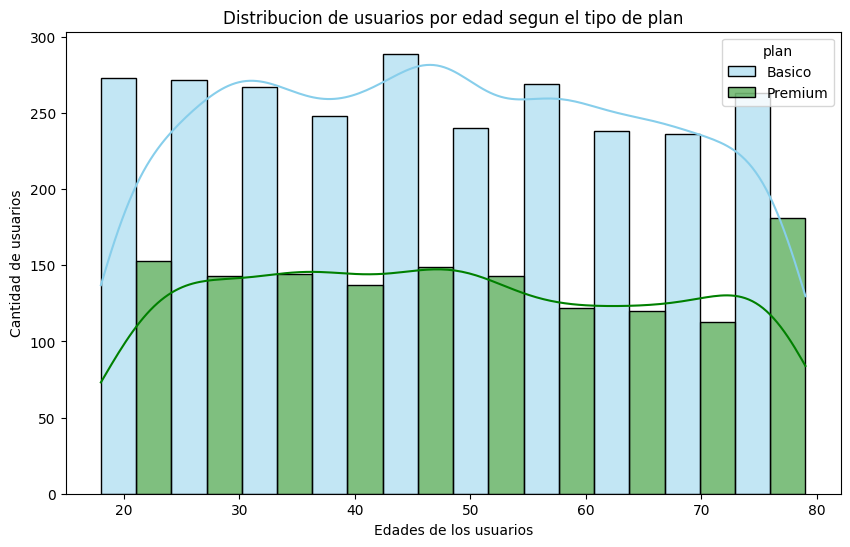

In [ ]:
# Histograma para visualizar la edad (age)
plt.figure(figsize=(10, 6))
sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=10,
    kde=True,
    multiple='dodge'
)

plt.xlabel('Edades de los usuarios')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribucion de usuarios por edad segun el tipo de plan')
plt.show()

💡Insights: El plan basico domina todas las categorias de las edades con aproximadamente el doble que cada categoria del plan basico
- Distribución simetrica

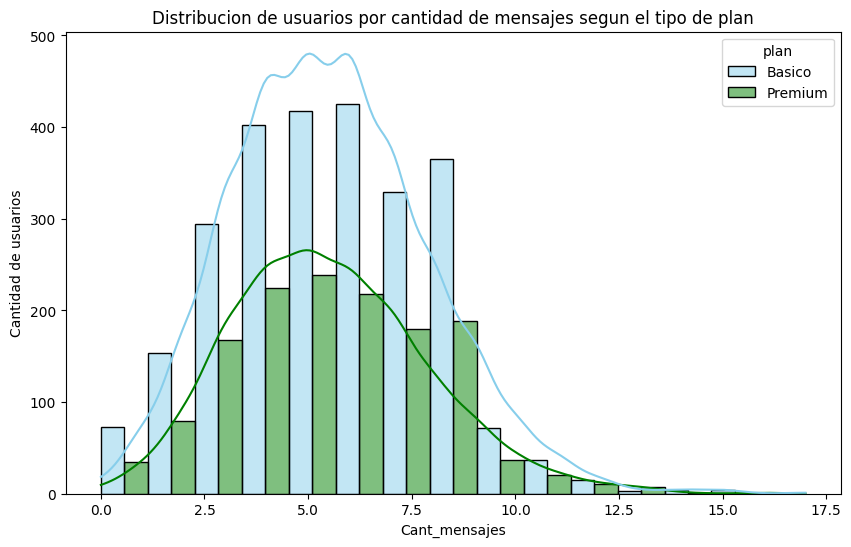

In [ ]:
# Histograma para visualizar la cant_mensajes
plt.figure(figsize=(10, 6))
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=15,
    kde=True,
    multiple='dodge'
)

plt.xlabel('Cant_mensajes')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribucion de usuarios por cantidad de mensajes segun el tipo de plan')
plt.show()

💡Insights: El plan basico supera ampliamente al plan premium en el volumen de usuario por cada ranga de cantidad de mensajes envidos
- Distribución presenta sesgo a la derecha o right-skewness

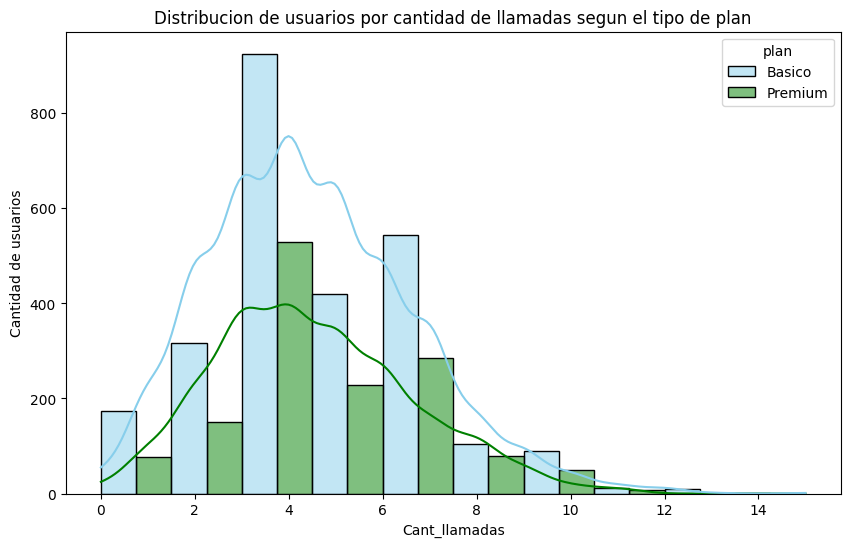

In [ ]:
# Histograma para visualizar la cant_llamadas
plt.figure(figsize=(10, 6))
sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=10,
    kde=True,
    multiple='dodge'
)

plt.xlabel('Cant_llamadas')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribucion de usuarios por cantidad de llamadas segun el tipo de plan')
plt.show()

💡Insights: los planes premium y basico muestran la cantidad de 4 llamadas como el valor top de ambos histogramas
- Distribución presenta un sesgo a la derecha

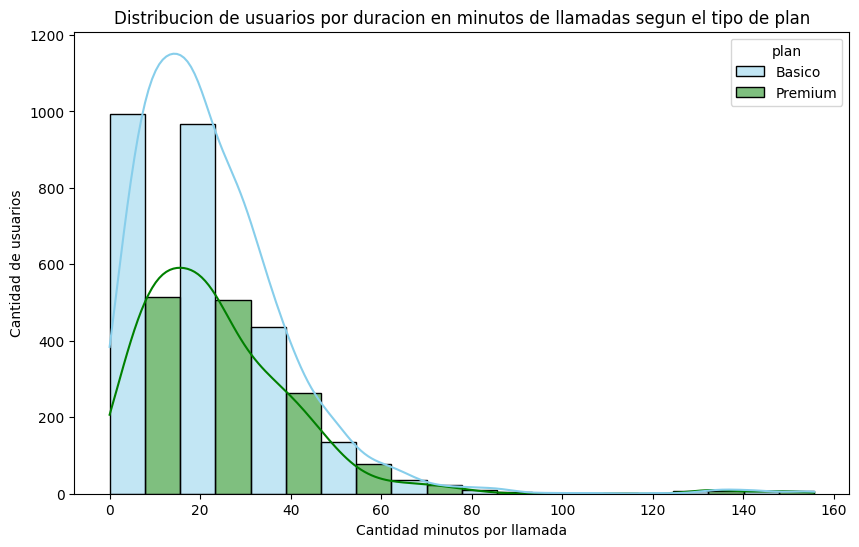

In [ ]:
# Histograma para visualizar la cant_minutos_llamada
plt.figure(figsize=(10, 6))
sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=10,
    kde=True,
    multiple='dodge'
)

plt.xlabel('Cantidad minutos por llamada')
plt.ylabel('Cantidad de usuarios')
plt.title('Distribucion de usuarios por duracion en minutos de llamadas segun el tipo de plan')
plt.show()

💡Insights: La mayor cantdiad de ambos tipos de planes prefieren realizar llamadas con una menor duracion por minutos
- Distribución presenta un  muy marcado sesgo a la derecha

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age`
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

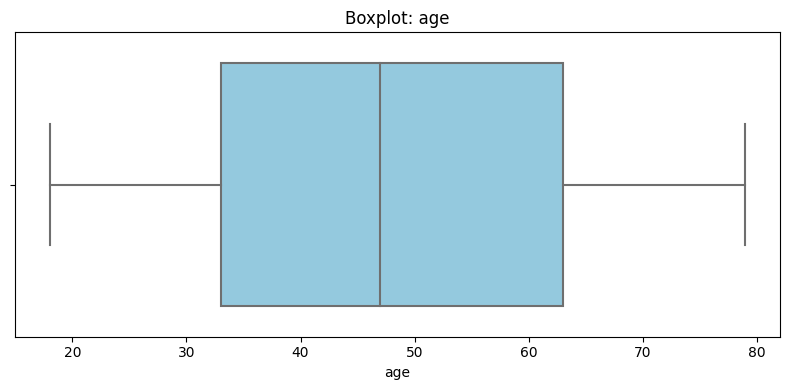

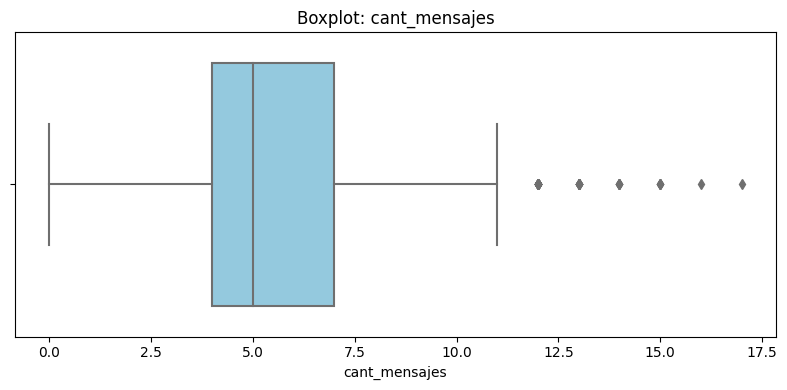

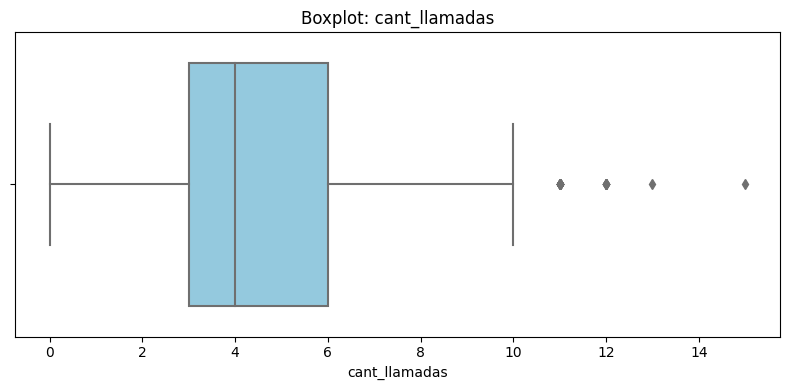

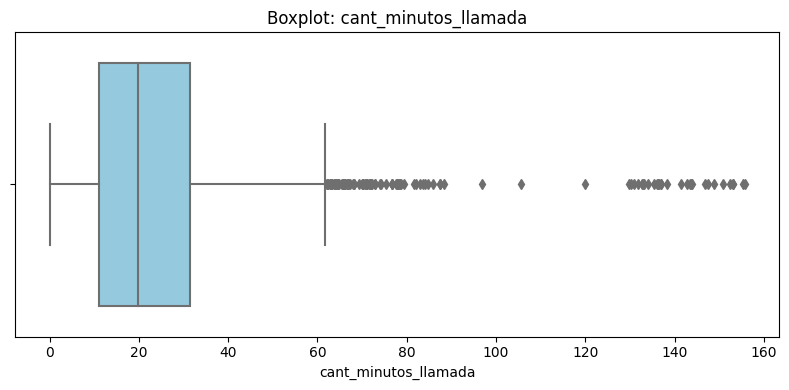

In [ ]:
# Visualizando usando BoxPlot
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']


for col in columnas_numericas:
    plt.figure(figsize=(8, 4))  # Define el tamaño de cada gráfico individual
    sns.boxplot(data=user_profile, x=col, color='skyblue')  # Genera el diagrama de caja
    plt.title(f'Boxplot: {col}')  # Asigna el título dinámico según el hint
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

💡Insights:
- Age: no presenta ningun outlaider todos sus valores estan dentro de rango
- cant_mensajes: prsenta un pequeño sesgo a la derecha por outlaider con una cantidad mayor de lo normal de cantidad de mensajes
- cant_llamadas: presenta un pequeño sesgo a la derecha por valores atipicos
- cant_minutos_llamada: presenta un marcado sesgo a la derecha debido a una gran cantidad de valores atipicos

In [ ]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes','cant_llamadas','cant_minutos_llamada']

def limites(col):
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    print('columna:', col)
    print('Q1:', Q1)
    print('Q3:', Q3)
    print('IQR:', IQR)
    print('Limite superior', upper)
    print()

for col in columnas_limites:
    limites(col)


columna: cant_mensajes
Q1: 4.0
Q3: 7.0
IQR: 3.0
Limite superior 11.5

columna: cant_llamadas
Q1: 3.0
Q3: 6.0
IQR: 3.0
Limite superior 10.5

columna: cant_minutos_llamada
Q1: 11.12
Q3: 31.415
IQR: 20.295
Limite superior 61.8575



In [ ]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights:
- cant_mensajes: mantener outliers, porqué aunque el maximo es superior al limite superior es un compartamiento normal de usuarios acumular una cantiadad un poco elevada de dicha cantiadad de mensajes.
- cant_llamadas: mantener outliers, porqué los valores entre 11 y 15 llamadas superan el límite matemático del IQR de forma moderada, pero representan una actividad de llamadas totalmente admisible y natural en un entorno de telecomunicaciones. Conservarlos permite reflejar con fidelidad la variabilidad real del uso del servicio.
- cant_minutos_llamada: mantener outllier, porqué aunque el Max supere por mucho el limite superiror de una manera notable en terminos de negocio es una cantidad factible acumulable por un pequeño sector del negocio o usuarios estudiados.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [ ]:
# Crear columna grupo_uso
def clasificar_uso(row):
    cantidad_llamadas = row['cant_llamadas']
    cantidad_mensajes = row['cant_mensajes']

    if cantidad_llamadas < 5 and cantidad_mensajes < 5:
        return "Bajo uso"
    elif cantidad_llamadas < 10 and cantidad_mensajes < 10:
        return "Uso medio"
    else:
        return "Alto uso"

user_profile['grupo_uso'] = user_profile.apply(clasificar_uso, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [ ]:
# Crear columna grupo_edad
def clasificar_edad(row):
    edad = row['age']

    if edad < 30:
        return "Joven"
    elif edad < 60:
        return "Adulto"
    else:
        return "Adulto Mayor"

user_profile['grupo_edad'] = user_profile.apply(clasificar_edad, axis=1)

In [ ]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

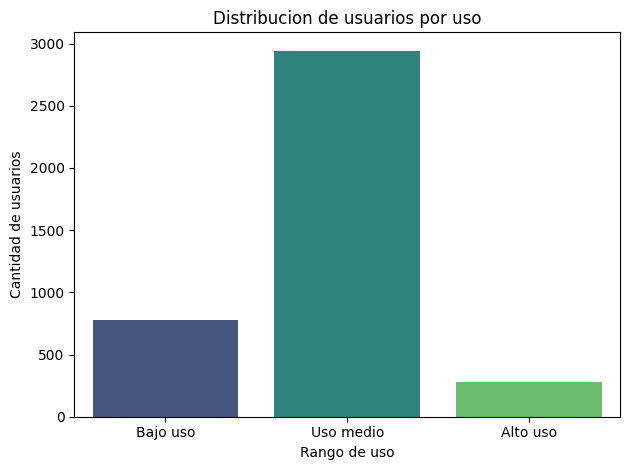

In [ ]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile, x='grupo_uso', palette='viridis', order=['Bajo uso','Uso medio','Alto uso'])
plt.title('Distribucion de usuarios por uso')
plt.xlabel('Rango de uso')
plt.ylabel('Cantidad de usuarios')
plt.tight_layout()

plt.show()

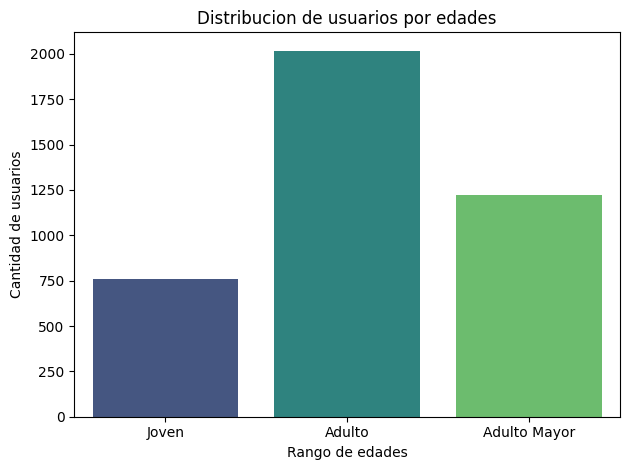

In [ ]:
# Visualización de los segmentos por edad
sns.countplot(data=user_profile, x='grupo_edad', palette='viridis', order=['Joven','Adulto','Adulto Mayor'])
plt.title('Distribucion de usuarios por edades')
plt.xlabel('Rango de edades')
plt.ylabel('Cantidad de usuarios')
plt.tight_layout()

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:**
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

- Los datasets originales presentaban inconsistencias críticas de calidad de datos, tales como registros de edad erróneos o extremos (ej. valores como $-999$), métricas de uso con cantidades negativas, y fechas de registro futuras (valores superiores al año 2024).
- Se realizaron dos segmentaciones adicionales al datased como lo seria la segmentacion por uso que incluye valores como Bajo uso, uso medio y alto uso y se realizo otra segmentacion por edad para clasificarlos entre Jovenes, Adultos y Adultos Mayores.
- la segmentacion por alto uso, Este grupo representa un valor estratégico clave para la compañía. Al sostener un volumen superior de llamadas, mensajes y minutos de voz, demuestran un alto nivel de dependencia y engagement con los servicios de telecomunicaciones, convirtiéndose en el blanco ideal para estrategias de retención, programas de lealtad y venta cruzada (cross-selling)
- Mediante la aplicación del método IQR, se detectaron valores máximos que superaban los límites superiores teóricos (por ejemplo, clientes con más de 17 mensajes, 15 llamadas o acumulados de más de 155 minutos de llamadas), Tras la revisión, se determinó que no son errores de captura, sino comportamientos orgánicos de consumo intenso. Para el negocio, esto implica que existe un subgrupo de clientes "power users" que exprimen al máximo la infraestructura de red, lo que justifica el diseño de productos específicos para ellos.
- Creación de un plan de alto rendimiento o "Ilimitado": Monetizar formalmente a los usuarios detectados como outliers y de alto consumo mediante un plan premium especializado que garantice beneficios de voz y mensajería extendida.

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Presencia de registros anómalos e inconsistencias críticas, tales como edades inválidas (ej. valores de $-999$), métricas de uso negativas y fechas de registro futuras superiores a 2024.
- Existencia de valores atípicos (outliers) en las variables de volumen de mensajes, llamadas y minutos, los cuales fueron evaluados mediante el método IQR para determinar su autenticidad.


🔍 **Segmentos por Edad**
- Distribución demográfica amplia, estable y multigeneracional que se extiende de manera homogénea desde los 20 hasta los 80 años.
- Se logra ver que el lider de este segemento son los Adultos los que mas utilizan los planes, sean premium basicos, esto en gran medida y como suposicion su trabajo los hacer estar con la necesidad de estar conectados mayor tiempo y en comunicacion continua.


📊 **Segmentos por Nivel de Uso**
- El segmento con mayor concentración de usuarios es el de 'Uso medio', lo que refleja un comportamiento operativo equilibrado en la base de clientes, centrado en interacciones rápidas y eficientes mediante un volumen moderado de mensajes y llamadas.
- La segmentación con menor cantidad de usuarios es "Alto uso", constituyendo un grupo reducido pero de alto valor estratégico para la compañía.

➡️ Esto sugiere que La segmentación comercial y las estrategias de valor deben diseñarse con base en la intensidad operativa de los usuarios (su nivel de interacción real) y no enfocarse exclusivamente en su segmentación por edad.


💡 **Recomendaciones**
- Desarrollar ofertas comerciales o paquetes especializados orientados a retener y monetizar al segmento de "Alto uso" y a los usuarios con patrones de consumo intensivo.
- Implementar mecanismos de notificación o upgrades automatizados para aquellos clientes que alcancen los límites superiores de su categoría actual.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`